## Rel gap (linear) plot with scheme-2 truncation at 0.1% and a y-axis tick at 0.1%

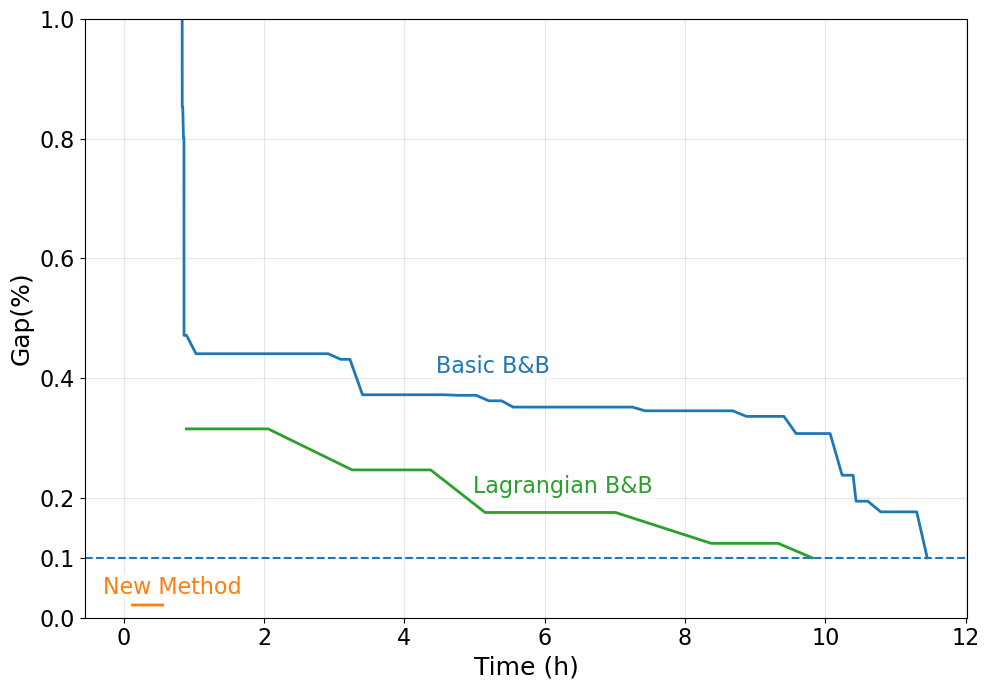

Saved: rel_gap_linear_generated_tick0p1.png


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Input files
csv_basic = "snog_5f.csv"
csv_lag   = "LG_K10_50cuts.csv"
csv_new   = "simp_1e3sc10_raw_post.csv"

GAP_THRESH = 0.1  # percent

def _norm(c: str) -> str:
    return "".join(ch for ch in str(c).lower() if ch.isalnum())

def pick_col(df, keys):
    for c in df.columns:
        n = _norm(c)
        if any(k in n for k in keys):
            return c
    raise ValueError(f"Could not find column for {keys} in columns={list(df.columns)}")

def parse_percent_series(s: pd.Series) -> pd.Series:
    ss = s.astype(str).str.strip()
    ss = ss.str.replace('%', '', regex=False)
    ss = ss.replace({'inf':'', 'Inf':'', 'INF':'', 'nan':'', 'NaN':''})
    return pd.to_numeric(ss, errors='coerce')

def load_gap(fp: str):
    df = pd.read_csv(fp)

    # time column (seconds)
    time_col = None
    for keys in (["times"], ["time"]):
        try:
            time_col = pick_col(df, keys)
            break
        except Exception:
            pass
    if time_col is None:
        raise ValueError("No time column found.")

    # rel gap column (percent)
    rel_col = None
    for keys in (["relgap"], ["relgap", "gap"], ["gap"]):
        try:
            rel_col = pick_col(df, keys)
            break
        except Exception:
            pass
    if rel_col is None:
        raise ValueError("No rel gap column found.")

    x = pd.to_numeric(df[time_col], errors='coerce')
    g = parse_percent_series(df[rel_col])
    mask = x.notna() & g.notna()
    x = x[mask].reset_index(drop=True) / 3600.0  # seconds -> hours
    g = g[mask].reset_index(drop=True)
    return x, g

def truncate_at_threshold(x: pd.Series, g: pd.Series, thresh: float):
    """Scheme 2: interpolate to y=thresh when crossing from above to below, then truncate."""
    if len(x) == 0:
        return x, g
    if not (g.min() < thresh) or not (g.max() > thresh):
        return x, g
    idxs = np.flatnonzero((g <= thresh).to_numpy())
    if len(idxs) == 0:
        return x, g
    i = int(idxs[0])
    if i == 0:
        return x.iloc[:1], g.iloc[:1]

    x1, y1 = float(x.iloc[i-1]), float(g.iloc[i-1])
    x2, y2 = float(x.iloc[i]),   float(g.iloc[i])

    if y1 == thresh:
        return x.iloc[:i], g.iloc[:i]

    if y1 == y2:
        x_star = x2
    else:
        x_star = x1 + (x2 - x1) * (y1 - thresh) / (y1 - y2)

    x_new = pd.concat([x.iloc[:i], pd.Series([x_star])], ignore_index=True)
    g_new = pd.concat([g.iloc[:i], pd.Series([thresh])], ignore_index=True)
    return x_new, g_new

# Load data
x_basic, g_basic = load_gap(csv_basic)
x_lag,   g_lag   = load_gap(csv_lag)
x_new,   g_new   = load_gap(csv_new)

# Scheme 2 truncation
x_basic, g_basic = truncate_at_threshold(x_basic, g_basic, GAP_THRESH)
x_lag,   g_lag   = truncate_at_threshold(x_lag,   g_lag,   GAP_THRESH)
x_new,   g_new   = truncate_at_threshold(x_new,   g_new,   GAP_THRESH)

# Plot
plt.figure(figsize=(10, 7))
ln_basic, = plt.plot(x_basic, g_basic, linewidth=2.0, label="Basic B&B")          # 保持默认蓝色
ln_lag,   = plt.plot(x_lag,   g_lag,   linewidth=2.0, label="Lagrangian B&B", color="tab:green")
ln_new,   = plt.plot(x_new,   g_new,   linewidth=2.0, label="New Method",       color="tab:orange")

plt.axhline(GAP_THRESH, linestyle="--", linewidth=1.5)

plt.xlabel("Time (h)", fontsize=18)
plt.ylabel("Gap(%)", fontsize=18)
plt.grid(True, which="both", alpha=0.3)

ax = plt.gca()
ax.tick_params(axis='both', labelsize=16)

# Optional: y-axis limits (set to None to keep auto)
ymin, ymax = 0, 1
if ymin is not None or ymax is not None:
    ax.set_ylim(ymin, ymax)

x0, x1 = ax.get_xlim()
dx_left = 0.03 * (x1 - x0) if (x1 > x0) else 0.0
# Per-label offsets in DATA coordinates: (dx_hours, dy_percent)
label_offset = {
    "Basic B&B": (-5.0, 0.32),
    "Lagrangian B&B": (-1.9, 0.12),
    "New Method": (1.5, 0.03),
}

def last_xy(x, y):
    if len(x) == 0:
        return None
    return float(x.iloc[-1]), float(y.iloc[-1])

# Inline labels near end (left of last point)
for name, ln, x, g in [
    ("Basic B&B", ln_basic, x_basic, g_basic),
    ("Lagrangian B&B", ln_lag, x_lag, g_lag),
    ("New Method", ln_new, x_new, g_new),
]:
    xy = last_xy(x, g)
    if xy is None:
        continue
    xe, ye = xy
    dx, dy = label_offset.get(name, (0.0, 0.0))

    ax.text(
        xe - dx_left + dx, ye + dy, name,
        fontsize=16, color=ln.get_color(),
        va="center", ha="right", clip_on=False,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1.0)
    )

# Add a y-tick at 0.1 (without changing limits)
yt = list(ax.get_yticks())
if not any(abs(t - GAP_THRESH) < 1e-12 for t in yt):
    yt.append(GAP_THRESH)
    yt = sorted(yt)
    ax.set_yticks(yt)

plt.tight_layout()

# Save output
out_png = "rel_gap_linear_generated_tick0p1.png"
plt.savefig(out_png, dpi=150)
plt.show()

print("Saved:", out_png)
